# Exploratory Data Analysis

One row per **market deal** (free agency / extension / offer sheet / RFA match / sign-and-trade, `years >= 2`) with a valid target. The target is `log_aav_cap_share` (log of average annual value as a fraction of the cap). 

Goal: understand the data and preview the market-size question before modeling.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

df = pd.read_csv("../data/model/features.csv")

# rfa_match (1 row) is an RFA offer another team made that was matched -> fold into offer_sheet
df["signed_via"] = df["signed_via"].replace({"rfa_match": "offer_sheet"})
# Missing fa_status means the deal was not a classic free agency (mostly extensions) -> own group
df["fa_status"] = df["fa_status"].fillna("n/a")

## 1. Dataset overview

In [2]:
df.shape

(1214, 73)

In [3]:
groups = {
    "target": ["aav_cap_share", "log_aav_cap_share"],
    "contract": ["years", "signed_via", "deal_type", "fa_status", "aav_m", "salary_cap_m"],
    "prior season": [c for c in df.columns if c.startswith("prior_") and c not in ("prior_team", "prior_team_big_market", "prior_team_market_size", "prior_team_metro_pop_m")],
    "career": ["career_seasons", "career_games", "career_ppg", "career_mpg", "career_vorp", "career_ws", "recent3_vorp", "recent3_ws"],
    "physical/draft": ["age_at_signing", "height_inches", "weight_lb", "years_pro", "draft_year"],
    "contract terms": ["incumbent", "player_option", "team_option", "max_tier_pct", "supermax", "outstanding_options"],
    "team context": ["team_srs", "team_nrtg", "team_mov", "team_wins", "team_made_playoffs", "team_champion", "team_cap_space_m", "team_active_payroll_m", "team_dead_cap_m", "team_players_active"],
    "prior team market": ["prior_team_big_market", "prior_team_market_size", "prior_team_metro_pop_m"],
    "market": ["team_big_market", "team_market_size", "team_metro_pop_m", "team_dma_rank", "team_tv_homes_m"],
}
for name, cols in groups.items():
    print(f"{name:>18} ({len(cols)}): {', '.join(cols)}")

            target (2): aav_cap_share, log_aav_cap_share
          contract (6): years, signed_via, deal_type, fa_status, aav_m, salary_cap_m
      prior season (20): prior_games, prior_ppg, prior_mpg, prior_per, prior_bpm, prior_vorp, prior_ws, prior_ws48, prior_usg_pct, prior_ts_pct, prior_srs, prior_nrtg, prior_mov, prior_wins, prior_made_playoffs, prior_champion, prior_cap_space_m, prior_active_payroll_m, prior_dead_cap_m, prior_players_active
            career (8): career_seasons, career_games, career_ppg, career_mpg, career_vorp, career_ws, recent3_vorp, recent3_ws
    physical/draft (5): age_at_signing, height_inches, weight_lb, years_pro, draft_year
    contract terms (6): incumbent, player_option, team_option, max_tier_pct, supermax, outstanding_options
      team context (10): team_srs, team_nrtg, team_mov, team_wins, team_made_playoffs, team_champion, team_cap_space_m, team_active_payroll_m, team_dead_cap_m, team_players_active
 prior team market (3): prior_team_big_market,

In [69]:
df.head()

,player_id,player_name,deal_date,deal_year,team,years,signed_via,deal_type,fa_status,aav_m,salary_cap_m,aav_cap_share,log_aav_cap_share,has_prior_stats,prior_games,prior_ppg,prior_mpg,prior_per,prior_bpm,prior_vorp,prior_ws,prior_ws48,prior_usg_pct,prior_ts_pct,career_seasons,career_games,career_ppg,career_mpg,career_vorp,career_ws,recent3_vorp,recent3_ws,age_at_signing,height_inches,weight_lb,years_pro,draft_year,incumbent,player_option,team_option,max_tier_pct,supermax,outstanding_options,team_srs,team_nrtg,team_mov,team_wins,team_made_playoffs,team_champion,team_cap_space_m,team_active_payroll_m,team_dead_cap_m,team_players_active,prior_team,prior_srs,prior_nrtg,prior_mov,prior_wins,prior_made_playoffs,prior_champion,prior_cap_space_m,prior_active_payroll_m,prior_dead_cap_m,prior_players_active,prior_team_big_market,prior_team_market_size,prior_team_metro_pop_m,team_big_market,team_market_size,team_metro_pop_m,team_dma_rank,team_tv_homes_m,cba_regime
0,abrinal01,Álex Abrines,"Jul 23, 2016",2016,OKC,3,free_agency,standard,RFA,5.733,94.143,0.060900,-2.798518,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,23,78,200,0,2013.0,1,0,0,0.25,0,0,7.09,7.5,7.28,55.0,1.0,0.0,-24.713,93.765,NaN,15.0,OKC,7.09,7.5,7.28,55.0,1.0,0.0,-24.713,93.765,NaN,15.0,0,Small,1.435,0,Small,1.435,47.0,0.76270,pre_2017
1,acyqu01,Quincy Acy,"Jul 22, 2015",2015,SAC,2,free_agency,standard,UFA,1.015,70.000,0.014500,-4.233607,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,25,79,240,3,2012.0,1,0,0,0.25,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Small,2.453,0,Small,2.453,20.0,1.49792,pre_2017
2,acyqu01,Quincy Acy,"Jul 20, 2016",2016,DAL,2,free_agency,standard,UFA,1.115,94.143,0.011844,-4.435960,1,59.0,5.203,14.847,14.7,-0.1,0.4,2.5,0.137,13.1,0.6293,1,59.0,5.20,14.85,0.4,2.5,0.4,2.5,26,79,240,4,2012.0,0,0,0,0.25,0,0,-0.02,-0.3,-0.30,42.0,1.0,0.0,-4.044,71.199,1.898,15.0,SAC,-2.32,-2.4,-2.48,33.0,0.0,0.0,-2.671,71.734,0.938,15.0,0,Small,2.453,1,Large,7.943,4.0,3.26449,pre_2017
3,acyqu01,Quincy Acy,"Jan 30, 2017",2017,BKN,2,free_agency,standard,UFA,1.750,99.093,0.017660,-4.036443,1,38.0,5.842,14.684,11.8,-2.1,0.0,0.9,0.077,16.8,0.5652,2,97.0,5.45,14.78,0.4,3.4,0.4,3.4,27,79,240,5,2012.0,0,0,0,0.25,0,0,-6.74,-6.6,-6.73,20.0,0.0,0.0,10.413,65.406,18.324,15.0,DAL,-2.53,-3.2,-2.93,33.0,0.0,0.0,-9.941,92.128,11.956,15.0,1,Large,7.943,1,Large,19.113,1.0,7.49451,cba_2017
4,adamsst01,Steven Adams,"Oct 31, 2016",2016,OKC,4,extension,extension,n/a,25.000,94.143,0.265553,-1.325939,1,80.0,7.950,25.175,15.5,0.2,1.1,6.5,0.155,12.6,0.6208,1,80.0,7.95,25.18,1.1,6.5,1.1,6.5,23,83,265,3,2013.0,1,0,0,0.25,0,0,7.09,7.5,7.28,55.0,1.0,0.0,-24.713,93.765,NaN,15.0,OKC,7.09,7.5,7.28,55.0,1.0,0.0,-24.713,93.765,NaN,15.0,0,Small,1.435,0,Small,1.435,47.0,0.76270,pre_2017


In [5]:
print("same player + same deal_year:", df.duplicated(["player_id", "deal_year"]).sum())
print("same player + same deal_date:", df.duplicated(["player_id", "deal_date"]).sum())

same player + same deal_year: 9
same player + same deal_date: 0


9 players appear twice in the same calendar year (e.g., a mid-season extension on top of a July deal) — distinct events, not duplicates. This matters later for the player-grouped train/test split.

## 2. Missingness

In [6]:
miss = pd.DataFrame({"count": df.isna().sum(), "pct": (df.isna().mean() * 100).round(1)})
miss = miss[miss["count"] > 0].sort_values("count", ascending=False)
miss

,count,pct
prior_usg_pct,239,19.7
prior_ppg,239,19.7
prior_mpg,239,19.7
prior_per,239,19.7
prior_bpm,239,19.7
prior_vorp,239,19.7
prior_ws,239,19.7
prior_ws48,239,19.7
prior_games,239,19.7
prior_ts_pct,239,19.7


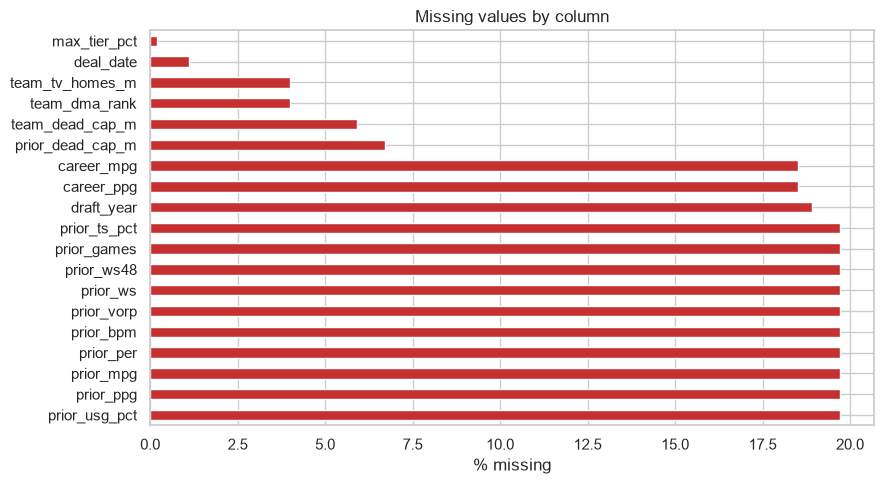

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
miss["pct"].plot.barh(ax=ax, color="#c53030")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()

Missingness is not random. 27% of deals have no prior-season stats (rookies / no NBA minutes in first season, flagged by `has_prior_stats`). ~36% of `fa_status` are extensions. Team-context rows are missing for 2015 deals (no 2014-15 team data) and historic teams. `team_dma_rank` is blank for Toronto (no Nielsen DMA).

## 3. Target variable

raw skew: 1.441
log skew: 0.018


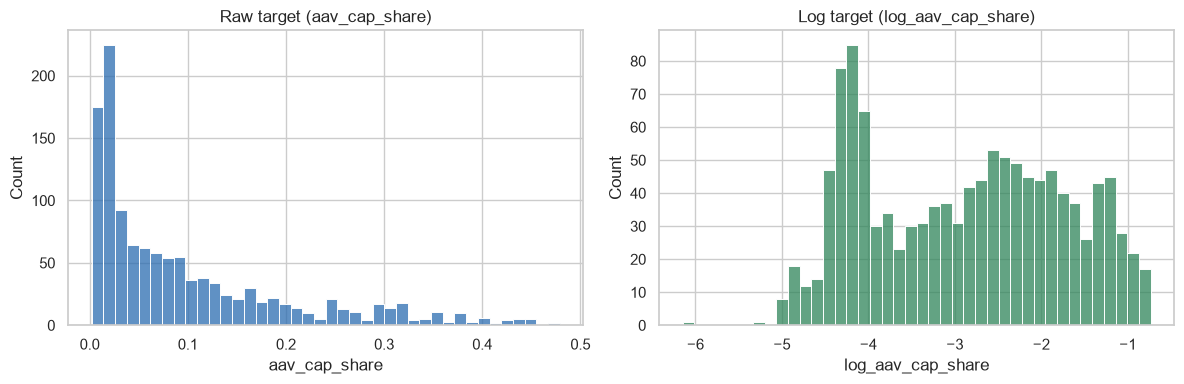

In [8]:
print("raw skew:", round(df.aav_cap_share.skew(), 3))
print("log skew:", round(df.log_aav_cap_share.skew(), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["aav_cap_share"], bins=40, ax=axes[0], color="#2b6cb0")
axes[0].set_title("Raw target (aav_cap_share)")
sns.histplot(df["log_aav_cap_share"], bins=40, ax=axes[1], color="#2f855a")
axes[1].set_title("Log target (log_aav_cap_share)")
plt.tight_layout()

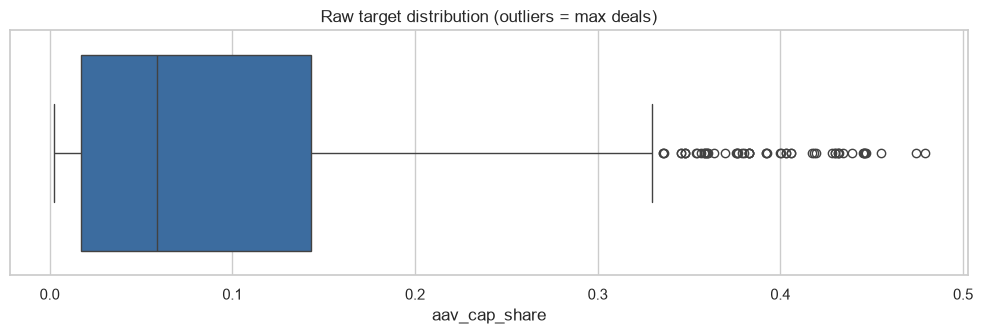

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.boxplot(data=df, x="aav_cap_share", ax=ax, color="#2b6cb0")
ax.set_title("Raw target distribution (outliers = max deals)")
plt.tight_layout()

In [10]:
df.nlargest(10, "aav_cap_share")[["player_name", "deal_year", "team", "signed_via", "aav_m", "aav_cap_share"]].round(3)

,player_name,deal_year,team,signed_via,aav_m,aav_cap_share
255,Stephen Curry,2021,GSW,extension,53.837,0.479
324,Joel Embiid,2021,PHI,extension,53.320,0.474
684,Damian Lillard,2022,POR,extension,56.290,0.455
1061,Jayson Tatum,2024,BOS,extension,62.800,0.447
591,Nikola Jokić,2022,DEN,extension,55.224,0.447
127,Devin Booker,2022,PHX,extension,55.110,0.446
1091,Karl-Anthony Towns,2022,MIN,extension,55.110,0.446
325,Joel Embiid,2024,PHI,extension,62.623,0.445
395,Shai Gilgeous-Alexander,2025,OKC,extension,67.915,0.439
176,Jimmy Butler,2021,MIA,extension,48.800,0.434


The raw target is right-skewed (skew ~1.4) and bounded at the max-salary ceiling. The log transform is near-symmetric (skew ~0), which is why we model `log_aav_cap_share`. The top deals are all max/supermax extensions and free-agent signings.

## 4. Categoricals vs Target

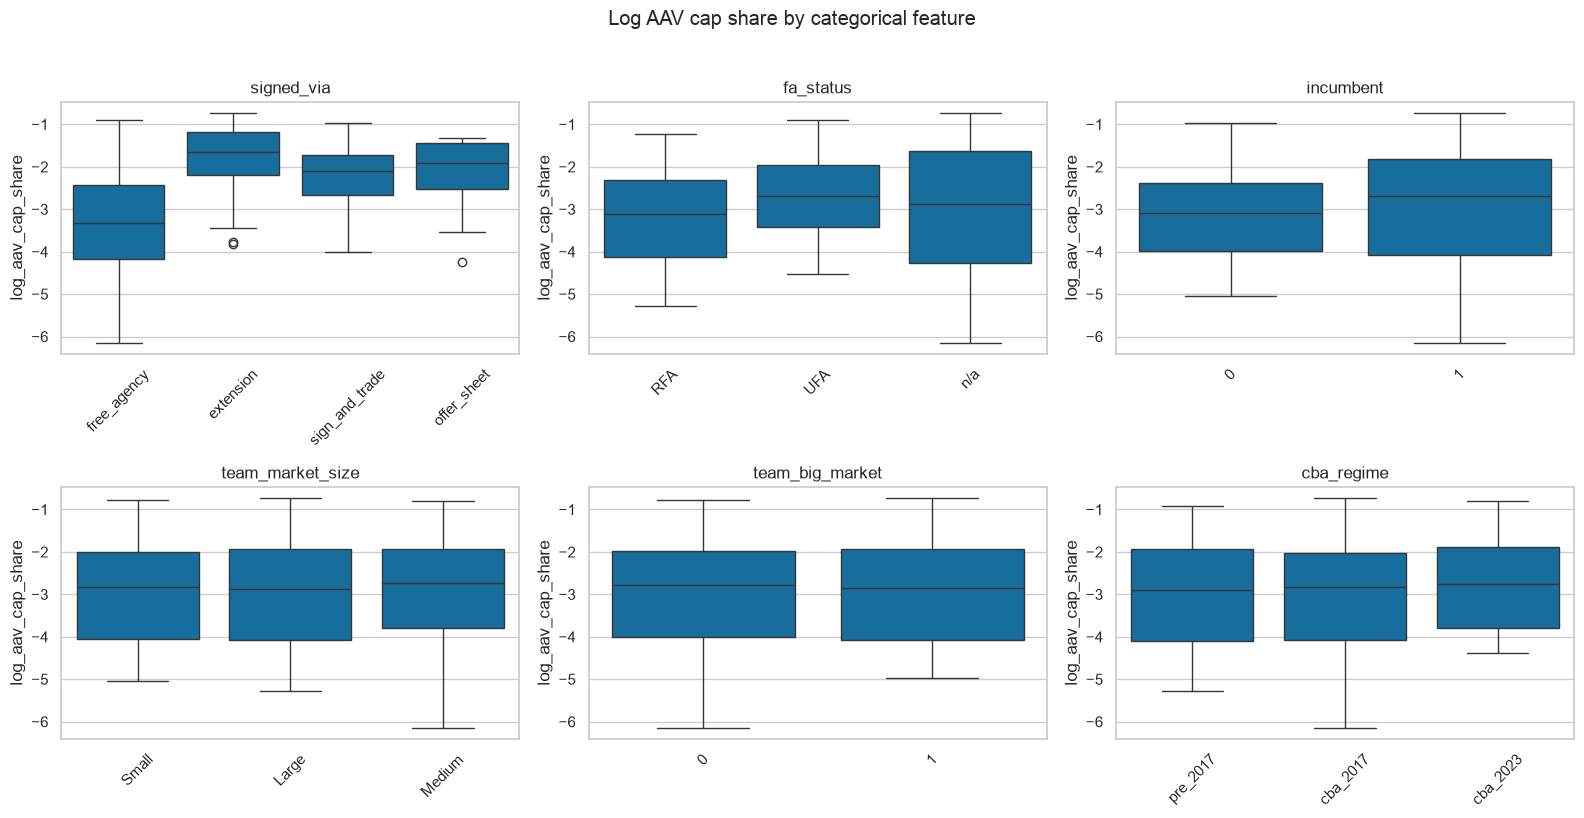

In [11]:
cats = ["signed_via", "fa_status", "incumbent", "team_market_size", "team_big_market", "cba_regime"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), cats):
    order = df[c].value_counts().index if c == "signed_via" else None
    sns.boxplot(data=df, x=c, y="log_aav_cap_share", order=order, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Log AAV cap share by categorical feature", y=1.02)
plt.tight_layout()

In [12]:
for c in cats:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False).to_string())
    print()

--- signed_via ---
signed_via
free_agency       928
extension         224
sign_and_trade     44
offer_sheet        18

--- fa_status ---
fa_status
UFA    478
n/a    441
RFA    295

--- incumbent ---
incumbent
1    857
0    357

--- team_market_size ---
team_market_size
Large     585
Small     397
Medium    232

--- team_big_market ---
team_big_market
0    669
1    545

--- cba_regime ---
cba_regime
cba_2017    629
cba_2023    312
pre_2017    273



In [13]:
df.groupby("signed_via")["aav_cap_share"].describe()[["count", "mean", "50%", "std"]].round(4)

,count,mean,50%,std
signed_via,,,,
extension,224.0,0.2140,0.1926,0.1191
free_agency,928.0,0.0693,0.0364,0.0794
offer_sheet,18.0,0.1470,0.1489,0.0880
sign_and_trade,44.0,0.1360,0.1215,0.0891


In [14]:
df.groupby("max_tier_pct")["aav_cap_share"].describe()[["count", "mean", "50%", "max"]].round(4)

,count,mean,50%,max
max_tier_pct,,,,
0.25,753.0,0.0667,0.0281,0.4743
0.30,211.0,0.1398,0.1173,0.4454
0.35,247.0,0.1663,0.1145,0.4789


Extensions and offer sheets pay materially more on average than free agency (incumbency leverage mostly), and the max-tier ceiling (0.25 / 0.30 / 0.35) clearly raises average pay. `incumbent` captures the same idea binary-wise.

## 5. Numerics vs Target

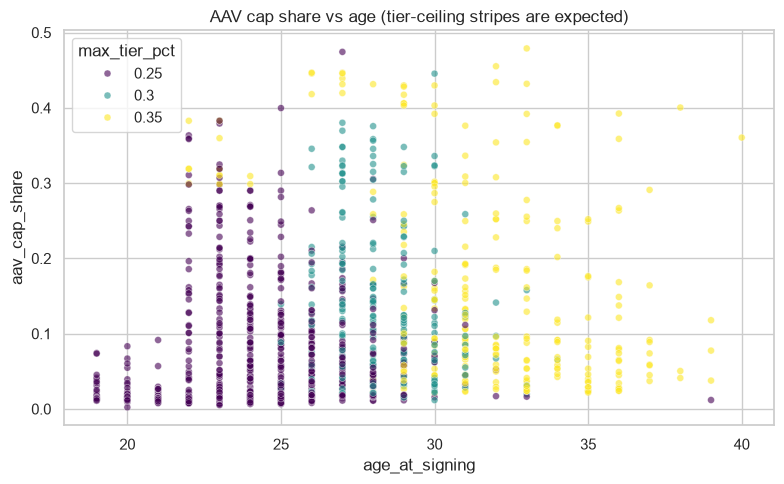

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="age_at_signing", y="aav_cap_share", hue="max_tier_pct",
                palette="viridis", alpha=0.6, ax=ax, s=25)
ax.set_title("AAV cap share vs age (tier-ceiling stripes are expected)")
plt.tight_layout()

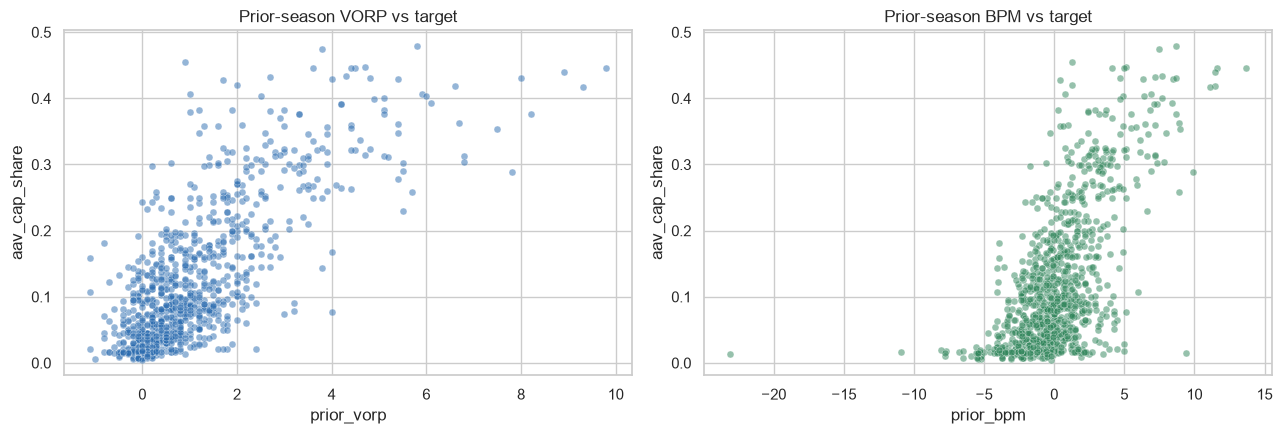

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=df, x="prior_vorp", y="aav_cap_share", alpha=0.5, ax=axes[0], color="#2b6cb0", s=25)
axes[0].set_title("Prior-season VORP vs target")
sns.scatterplot(data=df, x="prior_bpm", y="aav_cap_share", alpha=0.5, ax=axes[1], color="#2f855a", s=25)
axes[1].set_title("Prior-season BPM vs target")
plt.tight_layout()

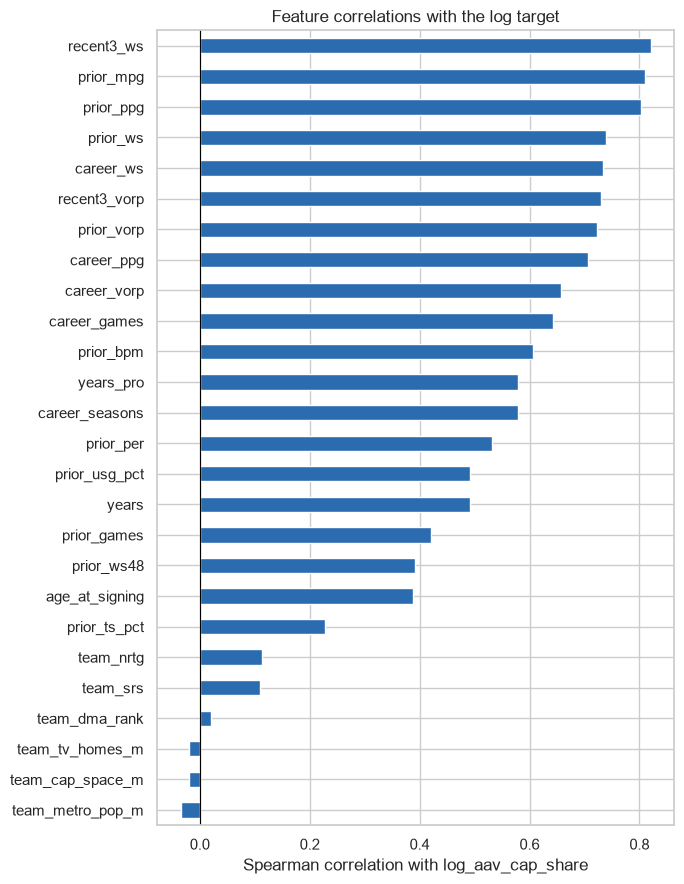

In [17]:
num = (["prior_games", "prior_ppg", "prior_mpg", "prior_per", "prior_bpm", "prior_vorp",
        "prior_ws", "prior_ws48", "prior_usg_pct", "prior_ts_pct"]
       + ["career_seasons", "career_games", "career_ppg", "career_vorp", "career_ws", "recent3_vorp", "recent3_ws"]
       + ["age_at_signing", "years_pro", "years", "team_srs", "team_nrtg", "team_cap_space_m",
          "team_metro_pop_m", "team_dma_rank", "team_tv_homes_m"])
corr = df[num + ["log_aav_cap_share"]].corr(method="spearman")["log_aav_cap_share"]\
    .drop("log_aav_cap_share").sort_values()
fig, ax = plt.subplots(figsize=(7, 9))
corr.plot.barh(ax=ax, color="#2b6cb0")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman correlation with log_aav_cap_share")
ax.set_title("Feature correlations with the log target")
plt.tight_layout()

Performance and usage drive pay, prior-season volume and impact stats (PPG, VORP, BPM, WS) and career/recent production all correlate positively with the target. `team_metro_pop_m` / `team_dma_rank` correlations are weak. Big markets don't obviously pay more in the raw data, so regression will re-examine this with controls.

## 6. Time & Context

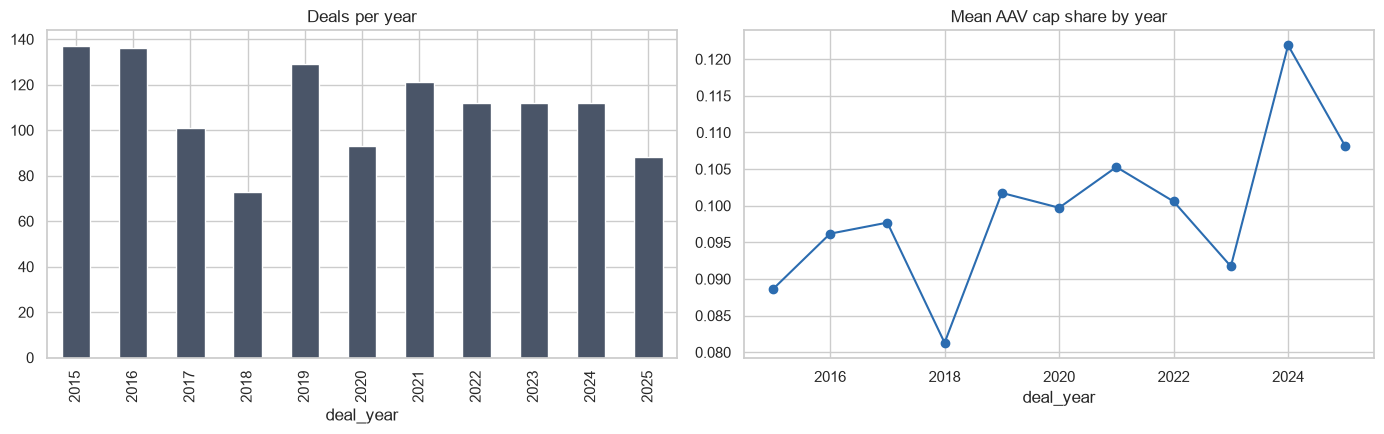

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
df["deal_year"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4a5568")
axes[0].set_title("Deals per year")
axes[0].set_xlabel("deal_year")
df.groupby("deal_year")["aav_cap_share"].mean().plot(ax=axes[1], marker="o", color="#2b6cb0")
axes[1].set_title("Mean AAV cap share by year")
axes[1].set_xlabel("deal_year")
plt.tight_layout()

### Mid-season signings
Most market deals are signed in the July free-agency window. Deals signed during the regular season (Nov-Apr) are a distinct category, typically extensions and offer-sheet/waiver transactions. How many?

total deals: 1214
  mid-season (Nov-Apr): 151 (12.6% of dated deals)
  off-season (May-Oct): 1050
  unknown deal_date: 13


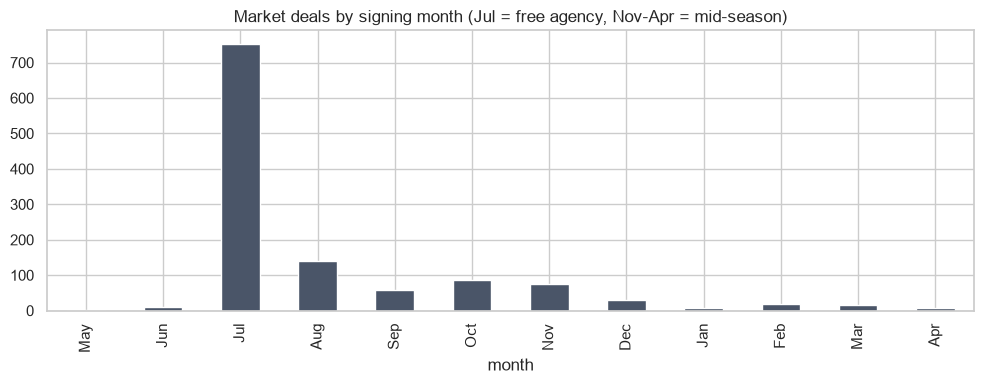

In [19]:
df["deal_month"] = df["deal_date"].str[:3]
mid_season_months = {"Nov", "Dec", "Jan", "Feb", "Mar", "Apr"}
known = df[df["deal_month"].notna()]
known = known[known["deal_month"] != ""]
known["mid_season"] = known["deal_month"].isin(mid_season_months)

order = ["May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr"]
counts = known["deal_month"].value_counts().reindex(order).fillna(0).astype(int)

mid_n = counts[["Nov", "Dec", "Jan", "Feb", "Mar", "Apr"]].sum()
print(f"total deals: {len(df)}")
print(f"  mid-season (Nov-Apr): {int(mid_n)} ({mid_n / len(known):.1%} of dated deals)")
print(f"  off-season (May-Oct): {int(counts[["May", "Jun", "Jul", "Aug", "Sep", "Oct"]].sum())}")
print(f"  unknown deal_date: {int(df['deal_date'].isna().sum())}")

fig, ax = plt.subplots(figsize=(10, 4))
counts.plot.bar(ax=ax, color="#4a5568")
ax.set_title("Market deals by signing month (Jul = free agency, Nov-Apr = mid-season)")
ax.set_xlabel("month")
plt.tight_layout()

151 of 1,201 dated deals (12.6%) were signed during the regular season (Nov-Apr). Signing month is a useful auxiliary signal for the modeling step, and mid-season deals should be checked for consistency with the prior-season feature timing.

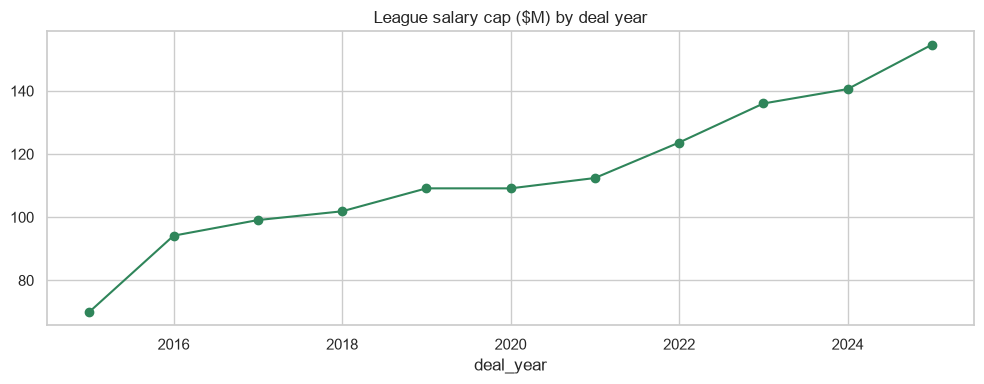

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby("deal_year")["salary_cap_m"].first().plot(marker="o", ax=ax, color="#2f855a")
ax.set_title("League salary cap ($M) by deal year")
ax.set_xlabel("deal_year")
plt.tight_layout()

Volume dips in 2018 (post-2017 cap-jump aftermath) and the cap-share target is already inflation-normalized (hence stable over time), but the 2016 spike and 2017 cap jump (94.1M -> 99.1M) still show. `cba_regime` and `deal_year` will be key context features.

## 7. Market focus

In [21]:
mkt = df.groupby("team_big_market")["aav_cap_share"].agg(["count", "mean", "median", "std"]).round(4)
mkt.index = ["small market", "big market"]
mkt

,count,mean,median,std
small market,669,0.0984,0.0614,0.1012
big market,545,0.1010,0.0577,0.1095


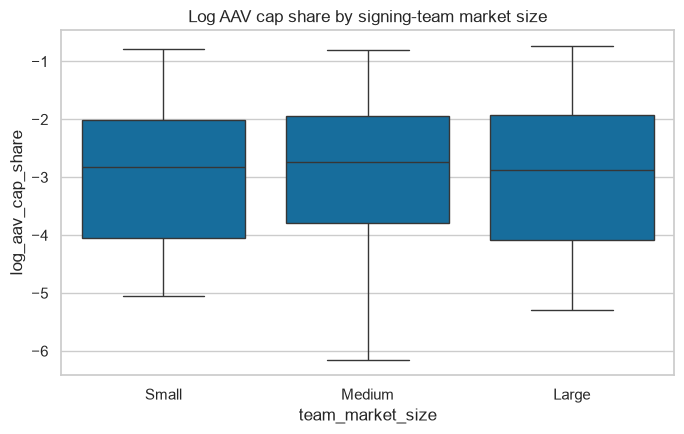

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x="team_market_size", y="log_aav_cap_share", order=["Small", "Medium", "Large"], ax=ax)
ax.set_title("Log AAV cap share by signing-team market size")
plt.tight_layout()

In [23]:
moves = df.groupby(["prior_team_big_market", "team_big_market"], dropna=False)["aav_cap_share"]\
    .agg(["count", "mean", "median"]).round(4)
moves.index.names = ["prior market", "signing market"]
moves

count    mean  median
prior market signing market                       
0            0                 588  0.1026  0.0649
             1                  91  0.0703  0.0418
1            0                  81  0.0682  0.0517
             1                 454  0.1071  0.0612

Raw big- vs small-market means are close (~10% vs ~9% of cap). Any real market effect is small relative to player quality. Deal counts are balanced across the two markets. This preview sets up the real test, which is controlling for player quality in the modeling step.

## Summary & next steps

- Target is clean and log-normalizable; max-tier ceilings and incumbency explain much of the variance.
- Performance features (prior VORP/BPM/PPG, career/recent production) are the strongest raw correlations.
- Market size shows little raw association with pay — the OLS-with-controls test in the modeling notebook will determine whether a controlled effect exists.
- Missingness is structural and already flagged (`has_prior_stats`, `fa_status = n/a`, TOR dma).
- Next: prep (encodings, imputation, player-grouped walk-forward split) in PREP.ipynb, then model in MODEL.ipynb.